# PERSIAPAN

In [38]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Load dataset
iris = load_iris()

In [5]:
# Membuat DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map(dict(enumerate(iris.target_names)))


# EKSPLORASI DATA AWAL

## Infromasi Dataset

Jumlah Data

In [55]:
jumlah_data = df.shape[0]
print("Jumlah Data :", jumlah_data)

Jumlah Data : 150


Jumlah Variabel

In [56]:
jumlah_variabel = df.shape[1]
print("Jumlah Variabel :", jumlah_variabel)

Jumlah Variabel : 5


Tipe data tiap variabel

In [57]:
tipe_data = df.dtypes
print("\nTipe Data Tiap Variabel:\n", tipe_data)


Tipe Data Tiap Variabel:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object


Jumlah masing masing spesies

In [58]:
jumlah_species = df['species'].value_counts()
print("\nJumlah Masing-masing Species:\n", jumlah_species)


Jumlah Masing-masing Species:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Statistik Deskriptif

Statistik deskriptif untuk semua variabel numerik
- Mean
- Median
- Standar Deviasi
- Minimum
- Maksimum

In [59]:
# Membuat DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Hitung statistik deskriptif
mean = df.mean()
median = df.median()
std = df.std()
minimum = df.min()
maximum = df.max()

# Gabungkan dalam satu tabel
statistik = pd.DataFrame({
    'Mean': mean,
    'Median': median,
    'Std Dev': std,
    'Minimum': minimum,
    'Maximum': maximum
})

print(statistik)

                       Mean  Median   Std Dev  Minimum  Maximum
sepal length (cm)  5.843333    5.80  0.828066      4.3      7.9
sepal width (cm)   3.057333    3.00  0.435866      2.0      4.4
petal length (cm)  3.758000    4.35  1.765298      1.0      6.9
petal width (cm)   1.199333    1.30  0.762238      0.1      2.5


## Visualisasi Distribusi

### Histogram

Histogram untuk variabel Sepal Length

---



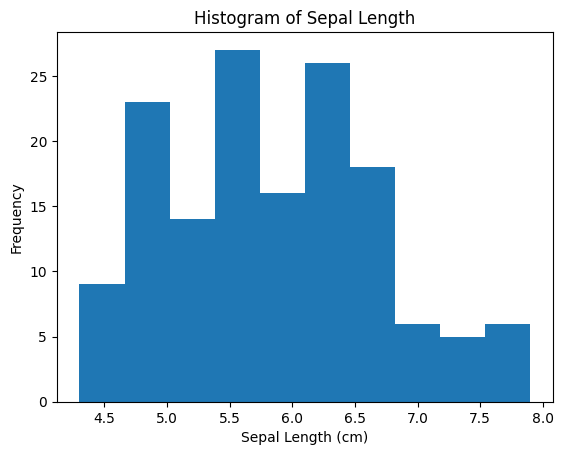

In [60]:
plt.figure()
plt.hist(df['sepal length (cm)'], bins=10)
plt.title('Histogram of Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')
plt.show()

Histogram untuk variabel Petal Length

Histogram untuk variabel Sepal Width

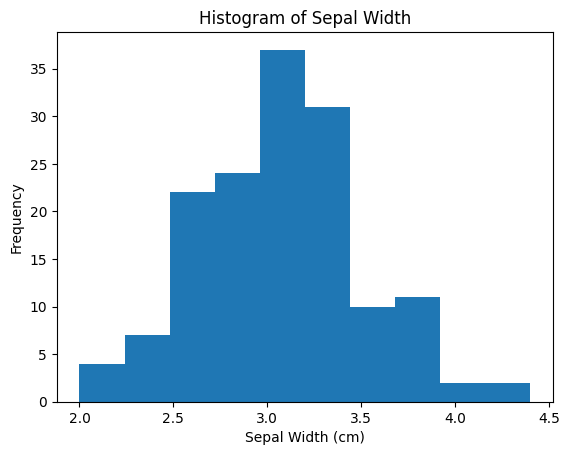

In [61]:
plt.figure()
plt.hist(df['sepal width (cm)'], bins=10)
plt.title('Histogram of Sepal Width')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Frequency')
plt.show()

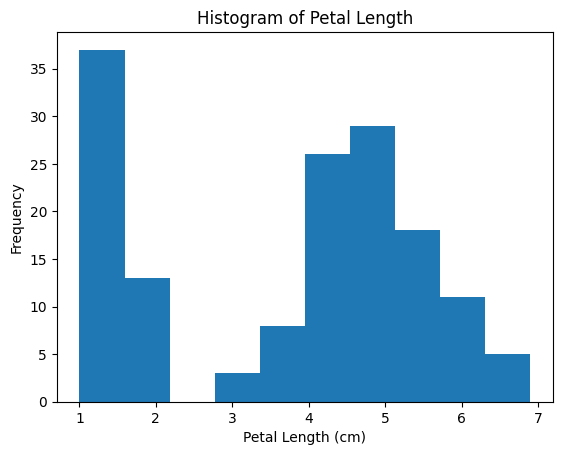

In [62]:
plt.figure()
plt.hist(df['petal length (cm)'], bins=10)
plt.title('Histogram of Petal Length')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Frequency')
plt.show()

Histogram untuk variabel Petal Width

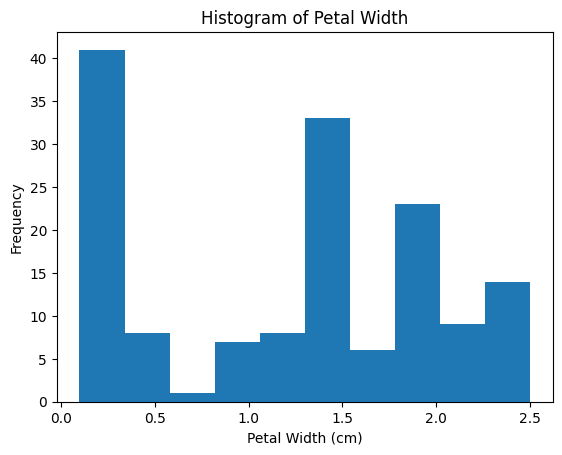

In [63]:
plt.figure()
plt.hist(df['petal width (cm)'], bins=10)
plt.title('Histogram of Petal Width')
plt.xlabel('Petal Width (cm)')
plt.ylabel('Frequency')
plt.show()

### Boxplot

Boxplot untuk variabel Sepal Length

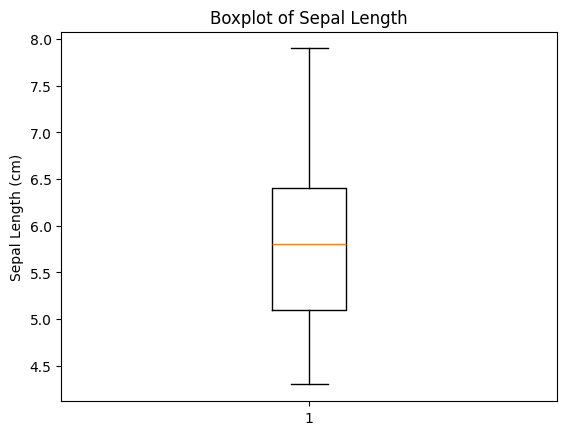

In [64]:
plt.figure()
plt.boxplot(df['sepal length (cm)'])
plt.title('Boxplot of Sepal Length')
plt.ylabel('Sepal Length (cm)')
plt.show()

Boxplot untuk variabel Sepal Width

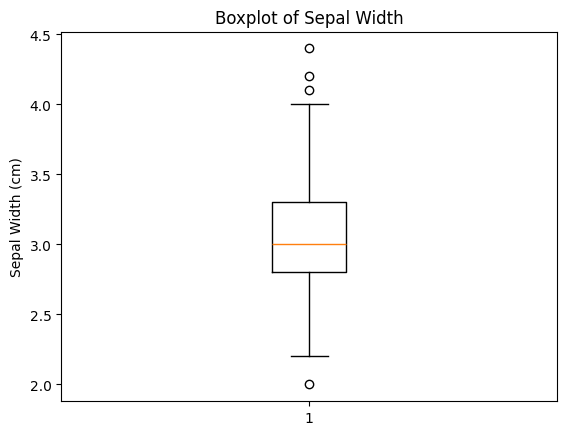

In [65]:
plt.figure()
plt.boxplot(df['sepal width (cm)'])
plt.title('Boxplot of Sepal Width')
plt.ylabel('Sepal Width (cm)')
plt.show()

Boxplot untuk variabel Petal Length

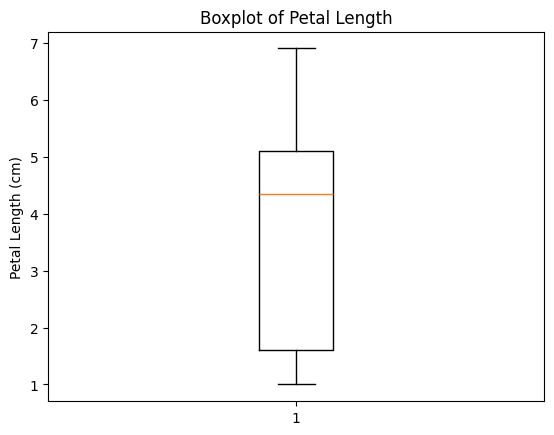

In [66]:
plt.figure()
plt.boxplot(df['petal length (cm)'])
plt.title('Boxplot of Petal Length')
plt.ylabel('Petal Length (cm)')
plt.show()

Boxplot untuk variabel Petal Width

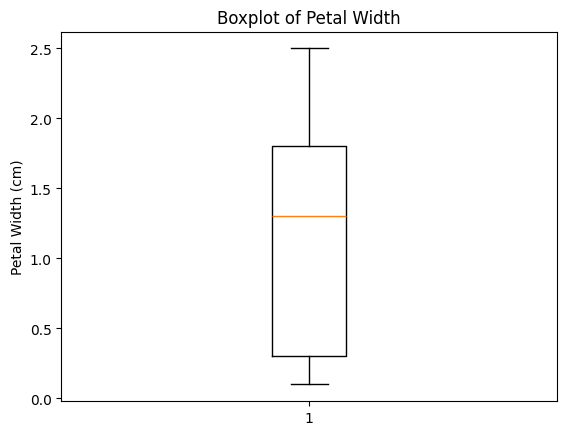

In [67]:
plt.figure()
plt.boxplot(df['petal width (cm)'])
plt.title('Boxplot of Petal Width')
plt.ylabel('Petal Width (cm)')
plt.show()

In [68]:
df['species'] = iris.target
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

## Visualisasi Berdasarkan Spesies

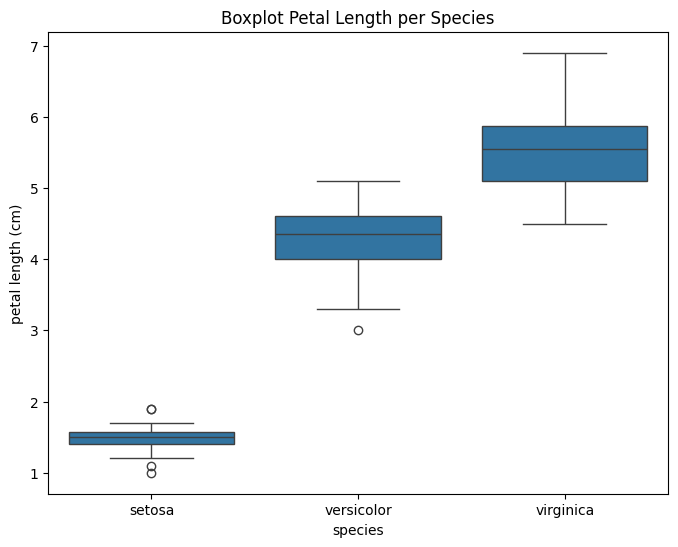

In [69]:
plt.figure(figsize=(8,6))
sns.boxplot(x='species', y='petal length (cm)', data=df)
plt.title('Boxplot Petal Length per Species')
plt.show()

Berdasarkan boxplot petal length per species pada dataset Iris dari scikit-learn, terlihat perbedaan yang cukup jelas antar ketiga spesies. Setosa memiliki panjang petal paling kecil, dengan median sekitar 1,5 cm dan rentang data yang sempit, menunjukkan variasi yang rendah serta hampir tidak ada tumpang tindih dengan spesies lain. Versicolor berada di posisi tengah dengan median sekitar 4,3 cm dan variasi yang lebih besar dibanding setosa; terdapat sedikit overlap dengan virginica pada nilai tertentu. Sementara itu, Virginica memiliki panjang petal paling besar dengan median sekitar 5,5 cm serta rentang yang paling lebar, menandakan variasi data yang lebih tinggi. Secara keseluruhan, perbedaan paling mencolok terlihat antara setosa dan dua spesies lainnya, sedangkan versicolor dan virginica relatif lebih berdekatan meskipun virginica cenderung memiliki nilai yang lebih tinggi.

# SAMPLING (BOOTSTRAP)

## Bootstrap Tunggal

In [41]:
petal_length = df['petal length (cm)']
bootstrap_sample = np.random.choice(petal_length,
                                    size=len(petal_length),
                                    replace=True)

In [43]:
# Ambil variabel petal length
petal_length = df['petal length (cm)']

# Bootstrap (sampling dengan pengembalian)
bootstrap_sample = np.random.choice(petal_length,
                                    size=len(petal_length),
                                    replace=True)

# Hitung statistik
mean_asli = petal_length.mean()
median_asli = petal_length.median()

mean_bootstrap = bootstrap_sample.mean()
median_bootstrap = np.median(bootstrap_sample)


In [44]:
# Membuat tabel perbandingan
tabel = pd.DataFrame({
    "Statistik": ["Mean", "Median"],
    "Data Aktual": [mean_asli, median_asli],
    "Bootstrap": [mean_bootstrap, median_bootstrap],
    "Selisih": [mean_bootstrap - mean_asli,
                median_bootstrap - median_asli]
})

print(tabel)

  Statistik  Data Aktual  Bootstrap   Selisih
0      Mean        3.758   3.702667 -0.055333
1    Median        4.350   4.400000  0.050000


Hasil bootstrap menunjukkan bahwa rata-rata dan median dari sampel bootstrap sangat dekat dengan data asli. Hal ini membuktikan bahwa metode bootstrap mampu merepresentasikan distribusi data asli dengan baik, meskipun sampel diambil secara acak dengan pengembalian.

## Bootstrap Berulang

In [45]:
# Ambil variabel petal length
petal_length = df['petal length (cm)']

# Fungsi bootstrap berulang
def bootstrap_mean(data, n_bootstrap):
    means = []
    for i in range(n_bootstrap):
        sample = np.random.choice(data,
                                  size=len(data),
                                  replace=True)
        means.append(np.mean(sample))
    return np.array(means)

# Bootstrap 100, 1000, 10000 kali
mean_100 = bootstrap_mean(petal_length, 100)
mean_1000 = bootstrap_mean(petal_length, 1000)
mean_10000 = bootstrap_mean(petal_length, 10000)

# Menampilkan ringkasan hasil
hasil = pd.DataFrame({
    "Jumlah Bootstrap": ["100", "1000", "10000"],
    "Rata-rata dari Mean Bootstrap": [
        mean_100.mean(),
        mean_1000.mean(),
        mean_10000.mean()
    ],
    "Standar Deviasi Mean Bootstrap": [
        mean_100.std(),
        mean_1000.std(),
        mean_10000.std()
    ]
})

print(hasil)

  Jumlah Bootstrap  Rata-rata dari Mean Bootstrap  \
0              100                       3.753373   
1             1000                       3.757911   
2            10000                       3.752846   

   Standar Deviasi Mean Bootstrap  
0                        0.137416  
1                        0.141956  
2                        0.144556  


In [46]:
# Membuat tabel perbandingan
tabel_perbandingan = pd.DataFrame({
    "Jumlah Bootstrap": ["Data Asli", "100", "1000", "10000"],
    "Mean": [
        mean_asli,
        mean_100.mean(),
        mean_1000.mean(),
        mean_10000.mean()
    ],
    "Selisih dari Mean Asli": [
        0,
        mean_100.mean() - mean_asli,
        mean_1000.mean() - mean_asli,
        mean_10000.mean() - mean_asli
    ]
})

print(tabel_perbandingan)

  Jumlah Bootstrap      Mean  Selisih dari Mean Asli
0        Data Asli  3.758000                0.000000
1              100  3.753373               -0.004627
2             1000  3.757911               -0.000089
3            10000  3.752846               -0.005154


## Visualisasi Hasil Bootstrap

### Histrogram

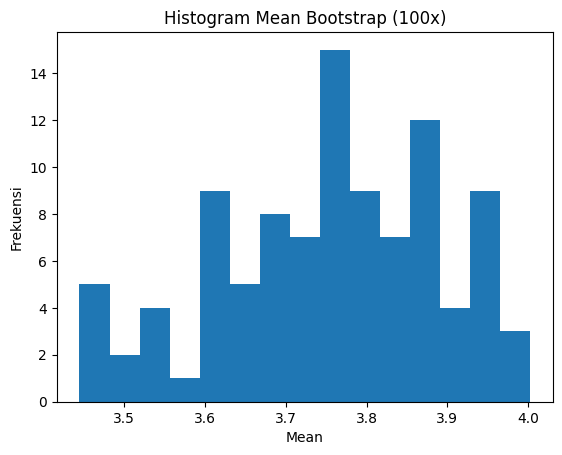

In [47]:
plt.figure()
plt.hist(mean_100, bins=15)
plt.title("Histogram Mean Bootstrap (100x)")
plt.xlabel("Mean")
plt.ylabel("Frekuensi")
plt.show()

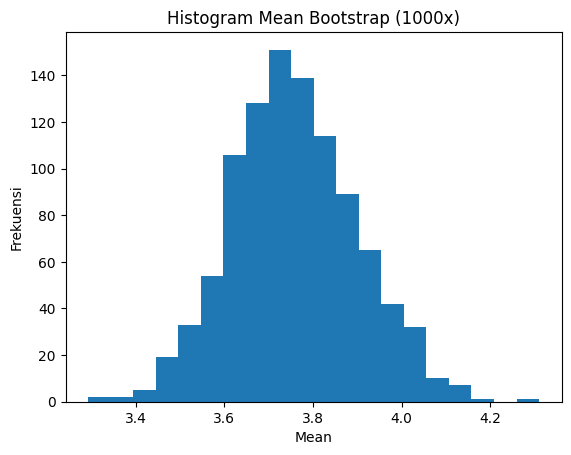

In [48]:
plt.figure()
plt.hist(mean_1000, bins=20)
plt.title("Histogram Mean Bootstrap (1000x)")
plt.xlabel("Mean")
plt.ylabel("Frekuensi")
plt.show()

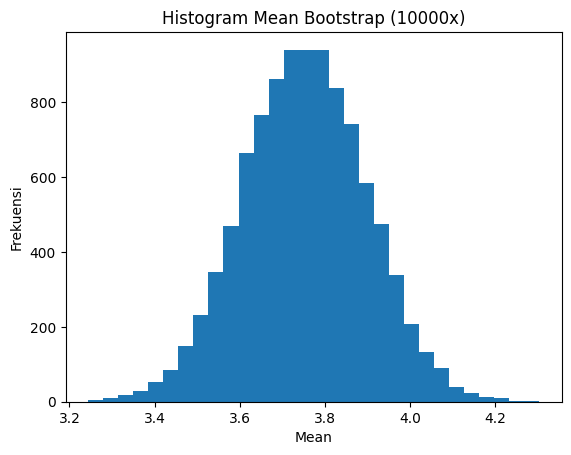

In [49]:
plt.figure()
plt.hist(mean_10000, bins=30)
plt.title("Histogram Mean Bootstrap (10000x)")
plt.xlabel("Mean")
plt.ylabel("Frekuensi")
plt.show()

### Boxplot

In [ ]:
plt.figure(figsize=(10, 6))
# Plot histogram dari bootstrap 10.000 kali
plt.hist(mean_10000, bins=30, color='skyblue', edgecolor='black', alpha=0.7, label='Distribusi Mean Bootstrap')

# Tambahkan garis untuk mean asli
plt.axvline(mean_asli, color='red', linestyle='dashed', linewidth=2, label=f'Mean Aktual: {mean_asli:.3f}')

plt.title('Perbandingan Distribusi Bootstrap Mean vs Nilai Aktual')
plt.xlabel('Mean Petal Length (cm)')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

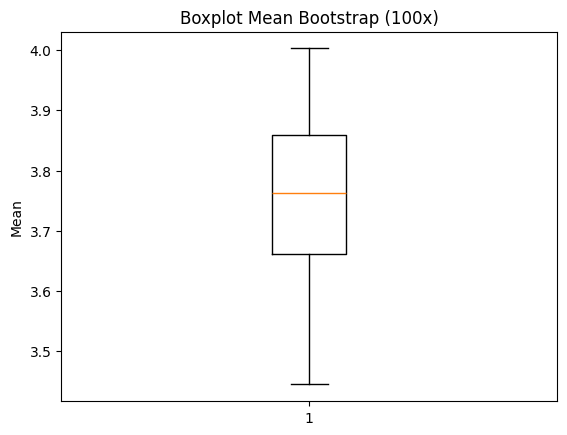

In [50]:
plt.figure()
plt.boxplot(mean_100)
plt.title("Boxplot Mean Bootstrap (100x)")
plt.ylabel("Mean")
plt.show()

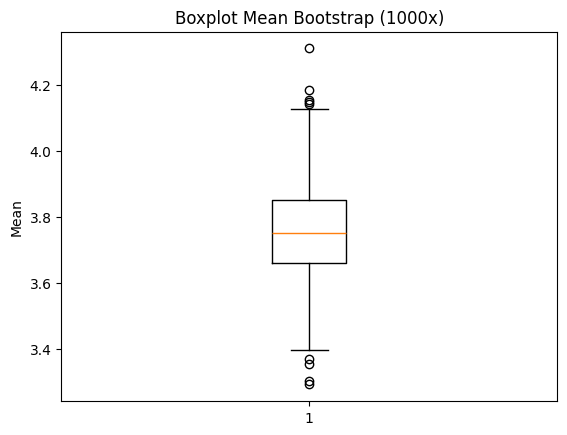

In [51]:
plt.figure()
plt.boxplot(mean_1000)
plt.title("Boxplot Mean Bootstrap (1000x)")
plt.ylabel("Mean")
plt.show()

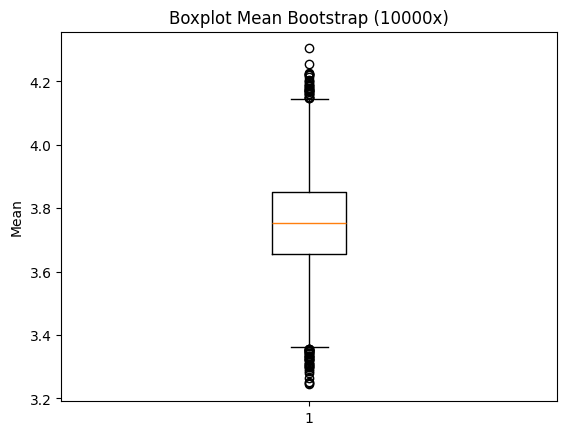

In [52]:
plt.figure()
plt.boxplot(mean_10000)
plt.title("Boxplot Mean Bootstrap (10000x)")
plt.ylabel("Mean")
plt.show()

## Interval Kepercayaan 95%

In [53]:
# Hitung CI 95% (metode persentil)
ci_100 = np.percentile(mean_100, [2.5, 97.5])
ci_1000 = np.percentile(mean_1000, [2.5, 97.5])
ci_10000 = np.percentile(mean_10000, [2.5, 97.5])

# Buat tabel perbandingan
tabel_ci = pd.DataFrame({
    "Jumlah Bootstrap": ["100", "1000", "10000"],
    "CI 2.5%": [ci_100[0], ci_1000[0], ci_10000[0]],
    "CI 97.5%": [ci_100[1], ci_1000[1], ci_10000[1]],
    "Lebar Interval": [
        ci_100[1] - ci_100[0],
        ci_1000[1] - ci_1000[0],
        ci_10000[1] - ci_10000[0]
    ]
})

print(tabel_ci)

  Jumlah Bootstrap   CI 2.5%  CI 97.5%  Lebar Interval
0              100  3.473933  3.977967        0.504033
1             1000  3.491950  4.038083        0.546133
2            10000  3.470000  4.034017        0.564017


# PERBANDINGAN DAN ANALISIS

## Apakah mean bootstrap mendekati mean data asli?

Mean bootstrap sangat mendekati data asli

Mean data asli = 3,758
sedangkan mean bootstrap adalah
- Bootstrap 100 → 3.753373 (selisih -0.004627)

- Bootstrap 1000 → 3.757911 (selisih -0.000089)

- Bootstrap 10000 → 3.752846
(selisih -0.005154)


Selisihnya sangat kecil, terutama pada 1000 bootstrap. Ini menunjukkan bahwa bootstrap mampu mengestimasi mean dengan baik.

## Bagaimana perubahan distribusi saat jumlah bootstrap bertambah?


Perubahan distribusi saat jumlah bootstrap bertambah menunjukkan bahwa semakin banyak replikasi bootstrap yang dilakukan, maka distribusi sampling mean menjadi semakin halus, stabil, dan mendekati bentuk distribusi normal. Pada 100 bootstrap, distribusi masih terlihat lebih kasar karena jumlah sampel ulang relatif sedikit sehingga variasinya masih cukup besar. Ketika jumlah bootstrap ditingkatkan menjadi 1000 dan 10000, distribusi menjadi lebih konsisten dan representatif terhadap estimasi parameter sebenarnya. Selain itu, interval kepercayaan yang dihasilkan juga menjadi lebih stabil dan tidak banyak mengalami perubahan yang signifikan.

## Mana yang lebih stabil: 100, 1000, atau 10000?


Dari ketiga jumlah bootstrap yang digunakan, yaitu 100, 1000, dan 10000, yang paling stabil adalah 10000 bootstrap. Hal ini karena semakin besar jumlah replikasi, maka estimasi mean akan semakin konvergen dan variasinya semakin kecil. Distribusi sampling menjadi lebih halus dan hasil interval kepercayaan lebih konsisten.

## Apakah mean asli berada dalam interval kepercayaan?

Mean asli berada dalam semua interval kepercayaan 95 %

- 100 → (3.473933 – 3.977967)

- 1000 → (3.491950 – 4.038083)

- 10000 → (3.470000 – 4.034017)

Karena 3.758 berada di dalam semua interval tersebut, maka estimasi bootstrap dapat dianggap valid dan tidak bias secara signifikan.

 ## Mengapa satu data bisa muncul berkali-kali pada bootstrap?

Satu data dapat muncul berkali-kali dalam metode bootstrap karena teknik yang digunakan adalah resampling with replacement. Artinya, setiap kali suatu observasi dipilih, data tersebut dikembalikan lagi ke dalam kumpulan sampel sehingga memiliki peluang yang sama untuk terpilih kembali pada pengambilan berikutnya

# KESIMPULAN

## Insight utama dari EDA dataset Iris

Exploratory Data Analysis (EDA) pada dataset Iris menunjukkan bahwa data memiliki distribusi yang relatif baik dan seimbang antar kelas (masing-masing spesies berjumlah 50 data). Variabel yang paling membedakan antar spesies adalah petal length dan petal width, karena keduanya menunjukkan pemisahan yang cukup jelas pada visualisasi scatter plot maupun boxplot. Sementara itu, sepal length dan sepal width memiliki tumpang tindih yang lebih besar antar spesies sehingga kurang kuat sebagai pembeda utama.

## Karakteristik tiap spesies (berdasarkan visualisasi)


1.   Setosa > memiliki ukuran petal paling kecil (petal length dan petal width rendah) dan terpisah sangat jelas dari dua spesies lainnya. Ini membuat setosa menjadi spesies yang paling mudah diklasifikasikan.
2.   Versicolor > memiliki ukuran petal sedang, berada di antara setosa dan virginica. Pada beberapa visualisasi, versicolor mulai menunjukkan sedikit tumpang tindih dengan virginica.
3. Virginica > memiliki ukuran petal paling besar (petal length dan petal width tinggi). Secara umum dapat dibedakan dari setosa dengan sangat jelas, namun masih terdapat overlap ringan dengan versicolor.


## Manfaat bootstrap dalam analisis data


Bootstrap bermanfaat untuk mengestimasi parameter statistik (seperti mean dan median) serta membangun interval kepercayaan tanpa harus mengasumsikan distribusi populasi tertentu. Metode ini sangat berguna ketika ukuran sampel terbatas atau ketika distribusi data tidak diketahui secara pasti. Dalam analisis ini, bootstrap menunjukkan bahwa estimasi mean sangat mendekati nilai asli dan mean asli berada dalam interval kepercayaan 95%.

## Jumlah bootstrap yang menurut Anda cukup

Berdasarkan hasil analisis, jumlah bootstrap sebanyak 1000 replikasi sudah cukup stabil. Nilai mean bootstrap sudah sangat mendekati mean asli dan distribusinya sudah halus serta konsisten. Meskipun 10000 memberikan hasil yang lebih stabil secara teoritis, peningkatan stabilitasnya tidak terlalu signifikan dibandingkan 1000, sementara kebutuhan komputasinya lebih besar. Oleh karena itu, 1000 bootstrap merupakan pilihan yang seimbang antara akurasi dan efisiensi komputasi.